In [1]:
import pandas as pd

df = pd.read_csv("../data/chennai_weather_raw.csv", index_col="time", parse_dates=True)
df.head()


,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max
time,,,,,
2023-01-01,28.6,21.3,0.0,84,13.0
2023-01-02,28.2,21.8,0.1,78,9.6
2023-01-03,27.8,22.0,0.3,76,17.7
2023-01-04,27.6,22.0,1.9,74,16.7
2023-01-05,28.5,25.0,0.0,69,22.2


In [2]:
df["temp_trend_3day"] = df["temperature_2m_max"].rolling(3).mean()
df["temp_max_tomorrow"] = df["temperature_2m_max"].shift(-1)
df_model = df.dropna()

In [3]:
print(df.shape)
df.info()

(731, 7)
<class 'pandas.DataFrame'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m_max         731 non-null    float64
 1   temperature_2m_min         731 non-null    float64
 2   precipitation_sum          731 non-null    float64
 3   relative_humidity_2m_mean  731 non-null    int64  
 4   windspeed_10m_max          731 non-null    float64
 5   temp_trend_3day            729 non-null    float64
 6   temp_max_tomorrow          730 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 45.7 KB


In [4]:
df.isnull().sum()

temperature_2m_max           0
temperature_2m_min           0
precipitation_sum            0
relative_humidity_2m_mean    0
windspeed_10m_max            0
temp_trend_3day              2
temp_max_tomorrow            1
dtype: int64

In [5]:
df.describe()

,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,temp_trend_3day,temp_max_tomorrow
count,731.000000,731.000000,731.000000,731.000000,731.000000,729.000000,730.000000
mean,32.097811,25.182763,4.426402,75.622435,18.807934,32.108230,32.102603
std,3.133351,2.147239,13.455244,7.958264,4.495513,3.023939,3.132818
min,25.100000,18.200000,0.000000,47.000000,9.600000,26.000000,25.100000
25%,29.400000,24.000000,0.000000,71.000000,15.600000,29.400000,29.400000
50%,32.000000,25.200000,0.500000,76.000000,18.400000,32.233333,32.000000
75%,34.400000,26.700000,3.600000,81.000000,21.750000,34.400000,34.400000
max,41.000000,30.400000,255.800000,92.000000,50.100000,40.866667,41.000000


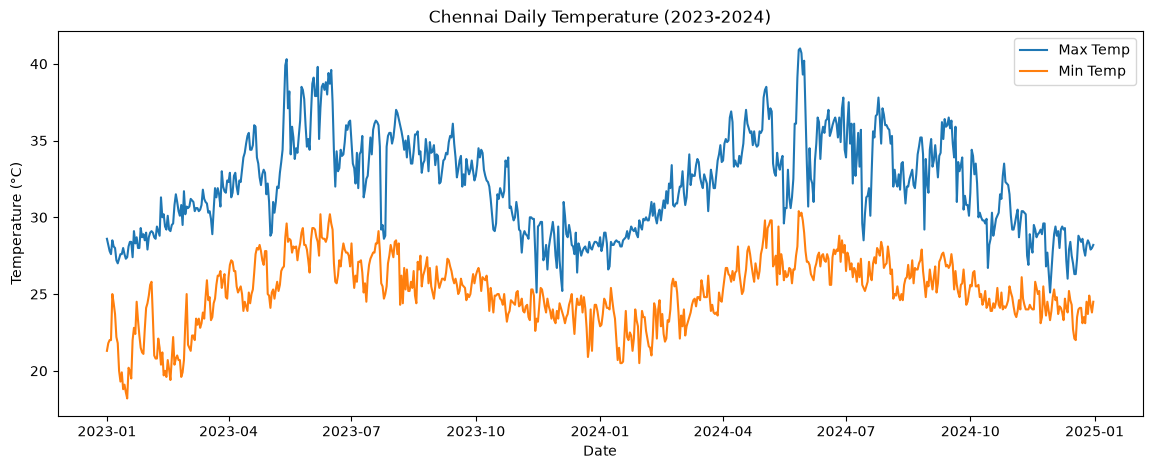

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["temperature_2m_max"], label="Max Temp")
plt.plot(df.index, df["temperature_2m_min"], label="Min Temp")
plt.title("Chennai Daily Temperature (2023-2024)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

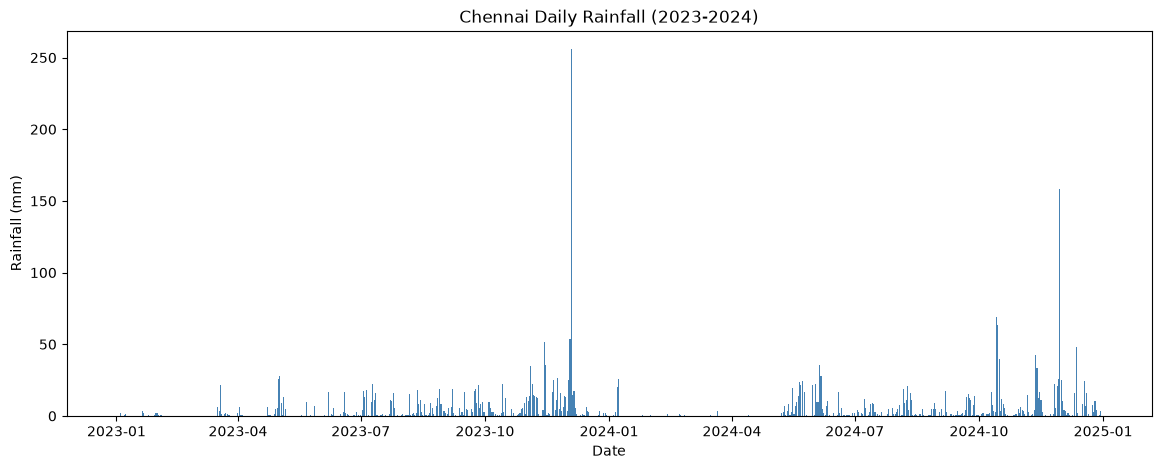

In [7]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df["precipitation_sum"], color="steelblue")
plt.title("Chennai Daily Rainfall (2023-2024)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

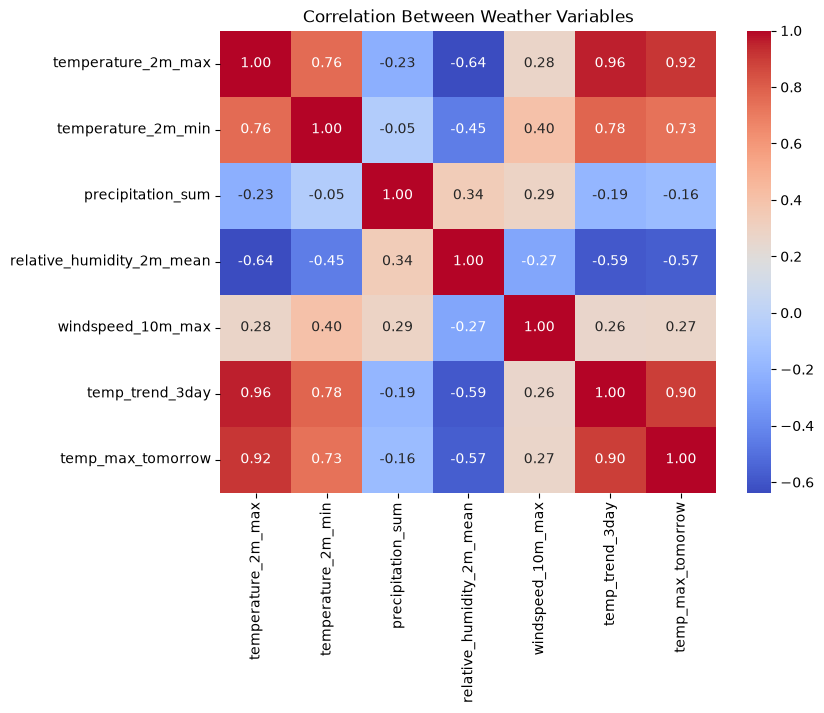

In [8]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Weather Variables")
plt.show()

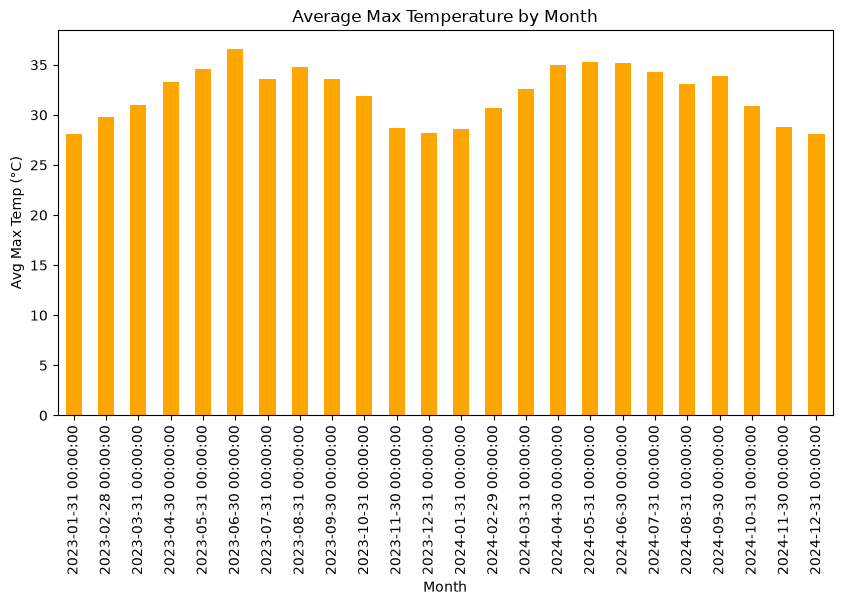

In [9]:
monthly_avg = df.resample("ME")["temperature_2m_max"].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="bar", color="orange")
plt.title("Average Max Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Avg Max Temp (°C)")
plt.show()

In [10]:
# Create a "target" column: tomorrow's max temperature
df["temp_max_tomorrow"] = df["temperature_2m_max"].shift(-1)

# Drop the last row since it won't have a "tomorrow" value
df_model = df.dropna()

df_model.head()

,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,temp_trend_3day,temp_max_tomorrow
time,,,,,,,
2023-01-03,27.8,22.0,0.3,76,17.7,28.200000,27.6
2023-01-04,27.6,22.0,1.9,74,16.7,27.866667,28.5
2023-01-05,28.5,25.0,0.0,69,22.2,27.966667,28.1
2023-01-06,28.1,24.4,0.0,71,24.5,28.066667,28.0
2023-01-07,28.0,23.7,0.9,74,22.3,28.200000,27.2


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Features = everything except the target
features = ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", 
            "relative_humidity_2m_mean", "windspeed_10m_max","temp_trend_3day"]
X = df_model[features]
y = df_model["temp_max_tomorrow"]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f}°C")

Mean Absolute Error: 0.88°C


In [12]:
import numpy as np

# Naive baseline: just guess "tomorrow = today"
baseline_predictions = X_test["temperature_2m_max"]
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
print(f"Naive Baseline MAE: {baseline_mae:.2f}°C")
print(f"Model MAE: {mae:.2f}°C")

Naive Baseline MAE: 0.93°C
Model MAE: 0.88°C


In [13]:
import numpy as np

# Naive baseline: just guess "tomorrow = today"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
baseline_predictions = X_test["temperature_2m_max"]
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
print(f"Naive Baseline MAE: {baseline_mae:.2f}°C")
print(f"Model MAE: {mae:.2f}°C")

Naive Baseline MAE: 0.93°C
Model MAE: 0.88°C


In [14]:
df["temp_trend_3day"] = df["temperature_2m_max"].rolling(3).mean()

In [15]:
import pickle

with open("../model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!
